<a href="https://colab.research.google.com/github/HussamAlabrash/DSA210PROJECT/blob/main/DSA210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importing Libraries

In [64]:
!pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## 2. Data Collection


In [65]:
from google.colab import files
uploaded = files.upload()

## 3. Loading the Data

In [66]:
econ = pd.read_csv("Middle_East_Economic_Data_1990_2024_with_Oil.csv")
conflict = pd.read_csv("MiddleEast_2015-2024_Nov01.csv")

## 4. Data Preparation

The conflict dataset is aggregated to create yearly country-level indicators such as total conflict events and fatalities.

In [67]:
conflict_agg = conflict.groupby(['country', 'year']).agg({
    'event_id_cnty': 'count',
    'fatalities': 'sum'
}).reset_index()

conflict_agg.rename(columns={
    'event_id_cnty': 'conflict_events'
}, inplace=True)

## 5. Filtering Data (2015–2024)

Only overlapping years between datasets are used.

In [68]:
econ_filtered = econ[(econ['Year'] >= 2015) & (econ['Year'] <= 2024)]

## 6. Merging Datasets

The datasets are merged using country and year.

In [69]:
# Make a safe copy to avoid pandas warning
econ_filtered = econ_filtered.copy()

# Clean country names to avoid mismatches
conflict_agg['country'] = conflict_agg['country'].str.strip().str.lower()
econ_filtered['Country'] = econ_filtered['Country'].str.strip().str.lower()

# Merge datasets
merged = econ_filtered.merge(
    conflict_agg,
    left_on=['Country', 'Year'],
    right_on=['country', 'year'],
    how='left'
)

# Fill missing conflict values
merged['conflict_events'] = merged['conflict_events'].fillna(0)
merged['fatalities'] = merged['fatalities'].fillna(0)

# Preview
merged.sample(10)

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel,country,year,conflict_events,fatalities
83,oman,OMN,2018,50.622442,6.120680,9.150585e+10,1.287104,19901.761564,38.656776,0.889312,79.864000,1.800,55.0,oman,2018.0,4.0,0.0
49,israel,ISR,2024,28.434762,2.734724,5.403799e+11,0.871968,54176.684438,26.017239,3.074809,NaN,3.595,85.0,israel,2024.0,4111.0,88.0
41,israel,ISR,2016,29.696009,3.723664,3.219410e+11,4.459783,37671.538914,28.103023,-0.535168,82.407317,4.723,65.0,israel,2016.0,209.0,20.0
75,lebanon,LBN,2020,16.372587,5.067130,3.171213e+10,-21.399900,5561.191670,33.757217,84.864333,76.299000,13.252,45.0,lebanon,2020.0,2991.0,48.0
40,israel,ISR,2015,30.861866,3.735533,3.034694e+11,2.237603,36213.104148,28.036106,-0.617343,82.051220,5.176,70.0,NaN,NaN,0.0,0.0
116,united arab emirates,ARE,2021,100.642574,4.892305,4.224414e+11,4.552786,44118.504719,82.266781,0.179935,79.083000,3.105,70.0,united arab emirates,2021.0,4.0,0.0
5,bahrain,BHR,2020,70.454436,2.849732,3.583763e+10,-5.911363,24342.844455,65.006549,-2.317706,78.683000,1.765,45.0,bahrain,2020.0,308.0,0.0
30,iraq,IRQ,2015,34.514146,-4.541592,1.667741e+11,2.606766,4440.141893,35.077622,1.393330,69.977000,10.865,70.0,NaN,NaN,0.0,0.0
29,iran,IRN,2024,23.551472,0.304914,4.752521e+11,3.663121,5190.169590,28.510659,32.455871,NaN,8.146,85.0,iran,2024.0,3290.0,310.0
89,oman,OMN,2024,66.072566,11.635118,1.071372e+11,1.631632,20285.227290,48.780105,0.593589,NaN,3.203,85.0,oman,2024.0,4.0,9.0


### Conflict Events vs GDP Growth

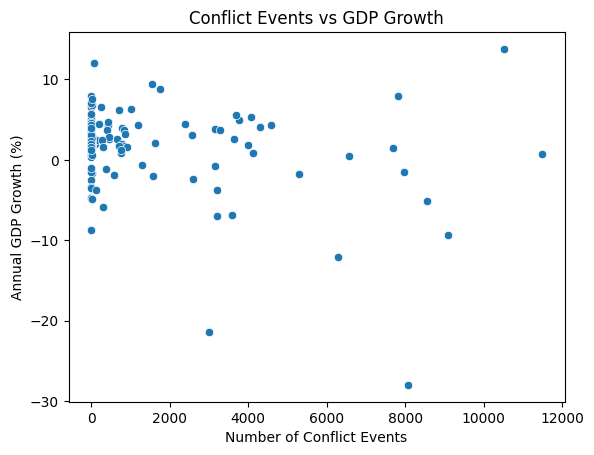

In [70]:
plt.figure()

sns.scatterplot(data=merged, x='conflict_events', y='GDP_growth_annual_pct')

plt.title("Conflict Events vs GDP Growth")
plt.xlabel("Number of Conflict Events")
plt.ylabel("Annual GDP Growth (%)")

plt.show()

This scatter plot illustrates the relationship between the number of conflict events and GDP growth across Middle Eastern countries. The points appear widely dispersed, indicating that the relationship is not very strong. However, there is a slight downward trend suggesting that higher levels of conflict may be associated with lower GDP growth. Additionally, observations with very high conflict events tend to correspond with more negative or volatile GDP growth values, highlighting the potential economic instability caused by conflict.

### Fatalities vs Inflation

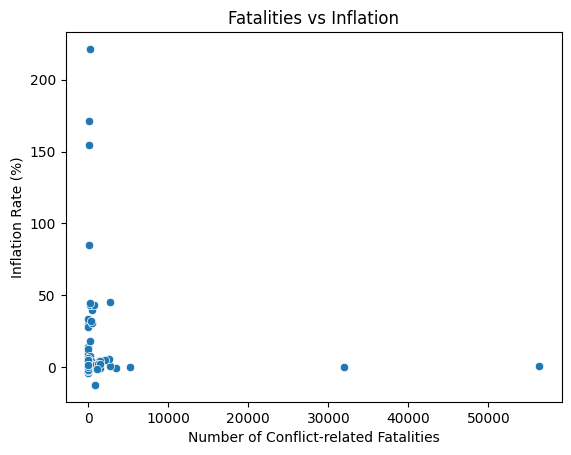

In [71]:
plt.figure()

sns.scatterplot(
    data=merged,
    x='fatalities',
    y='Inflation_consumer_prices_annual_pct'
)

plt.title("Fatalities vs Inflation")
plt.xlabel("Number of Conflict-related Fatalities")
plt.ylabel("Inflation Rate (%)")

plt.show()

This plot examines the relationship between conflict-related fatalities and inflation rates. The data points are scattered without a clear upward or downward trend, suggesting that there is no strong relationship between fatalities and inflation. This indicates that while conflict may influence economic conditions, its direct impact on inflation is not clearly observable in this dataset.

### Oil Price vs GDP Growth

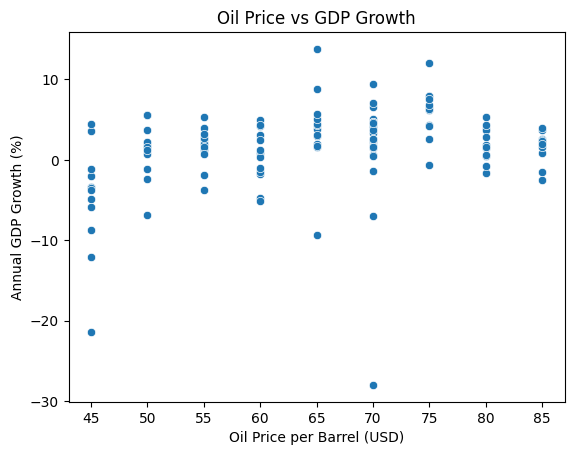

In [72]:
plt.figure()

sns.scatterplot(
    data=merged,
    x='Brent_Oil_Price_USD_per_barrel',
    y='GDP_growth_annual_pct'
)

plt.title("Oil Price vs GDP Growth")
plt.xlabel("Oil Price per Barrel (USD)")
plt.ylabel("Annual GDP Growth (%)")

plt.show()

This scatter plot shows the relationship between oil prices and GDP growth. A slight positive trend can be observed, indicating that higher oil prices are generally associated with higher GDP growth. This is expected for oil-dependent economies, where increases in oil prices contribute positively to national income and economic performance.

### Conflict Events Over Time

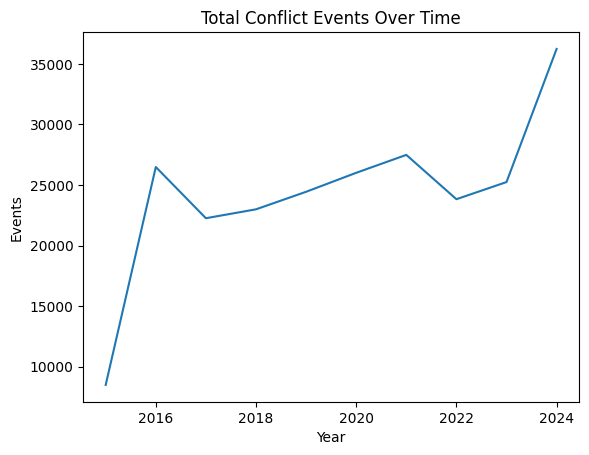

In [73]:
conflict_trend = merged.groupby('Year')['conflict_events'].sum()

plt.figure()
conflict_trend.plot()
plt.title("Total Conflict Events Over Time")
plt.xlabel("Year")
plt.ylabel("Events")
plt.show()

This scatter plot shows the relationship between oil prices and GDP growth. A slight positive trend can be observed, indicating that higher oil prices are generally associated with higher GDP growth. This is expected for oil-dependent economies, where increases in oil prices contribute positively to national income and economic performance.

## Additional Exploratory Data Analysis

To address more variables in the dataset, additional exploratory plots are created. These plots examine the distributions of economic indicators, compare GDP growth across countries, show trends over time, and summarize relationships among numerical variables.

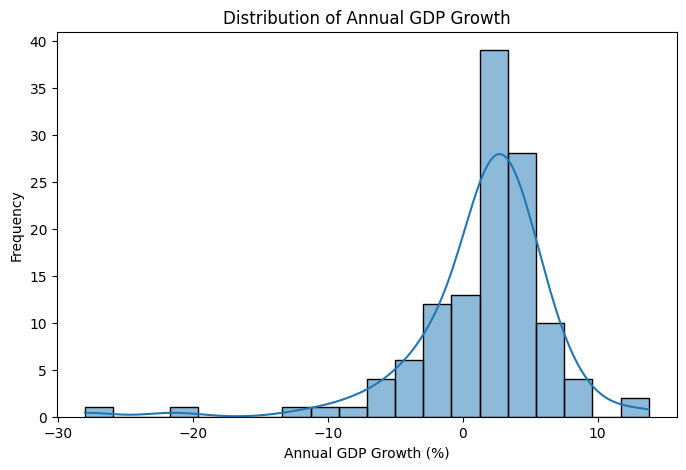

In [74]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=merged,
    x='GDP_growth_annual_pct',
    bins=20,
    kde=True
)

plt.title("Distribution of Annual GDP Growth")
plt.xlabel("Annual GDP Growth (%)")
plt.ylabel("Frequency")

plt.show()

This histogram shows the distribution of annual GDP growth values in the dataset. Most observations are concentrated around moderate growth levels, while some countries and years show very low or very high GDP growth. These extreme values suggest economic volatility in the region.

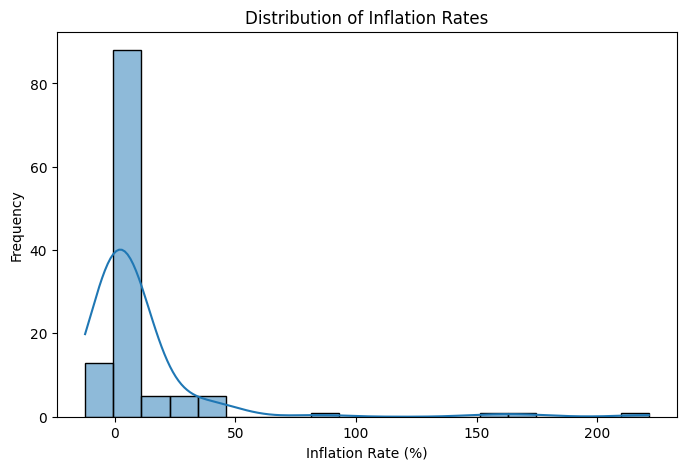

In [75]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=merged,
    x='Inflation_consumer_prices_annual_pct',
    bins=20,
    kde=True
)

plt.title("Distribution of Inflation Rates")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Frequency")

plt.show()

This histogram shows the distribution of inflation rates across countries and years. The distribution is right-skewed, meaning that most observations have relatively low inflation, while a few cases have extremely high inflation. These outliers may represent periods of economic instability.

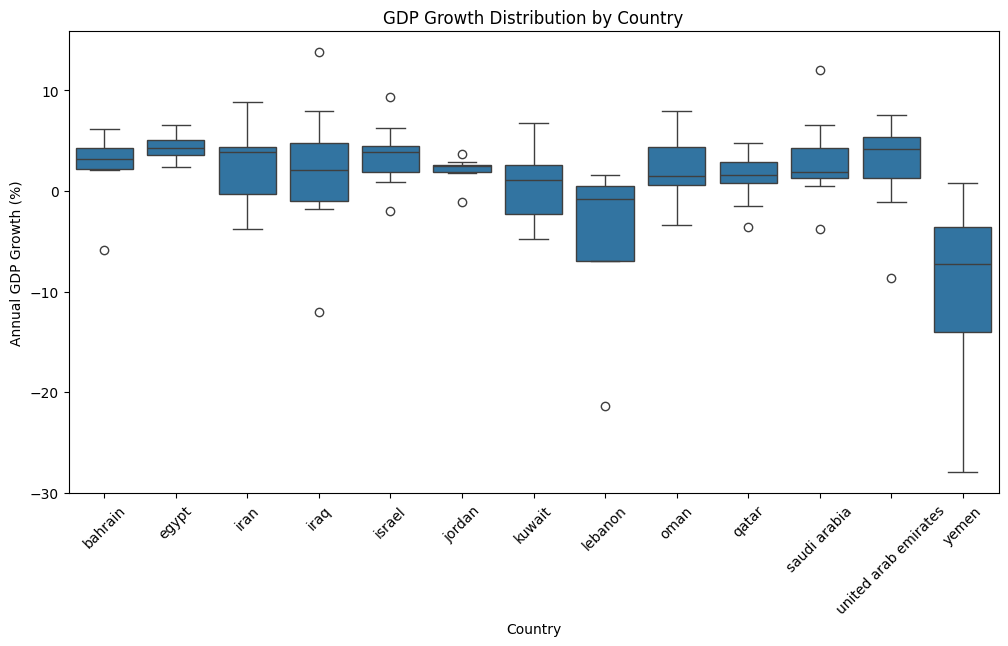

In [76]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=merged,
    x='Country',
    y='GDP_growth_annual_pct'
)

plt.title("GDP Growth Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Annual GDP Growth (%)")
plt.xticks(rotation=45)

plt.show()

This boxplot compares GDP growth distributions across countries. Some countries show relatively stable GDP growth, while others have wider spreads and more outliers. This indicates that economic performance varies substantially across Middle Eastern countries.

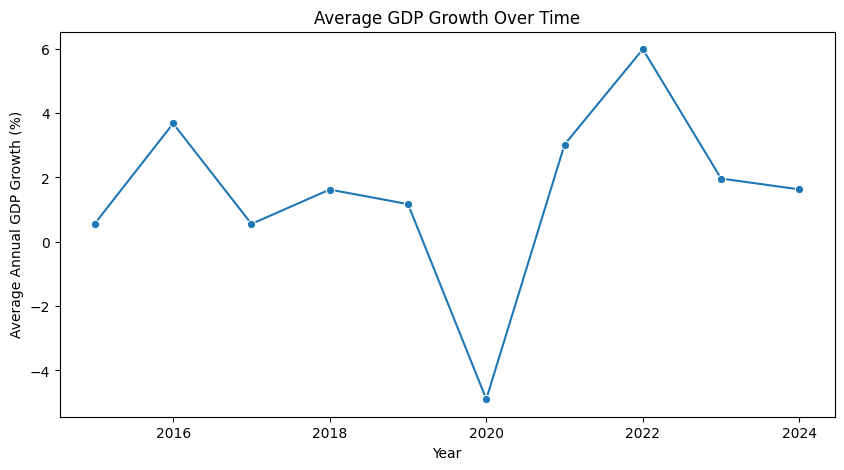

In [77]:
avg_gdp_by_year = merged.groupby('Year')['GDP_growth_annual_pct'].mean().reset_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=avg_gdp_by_year,
    x='Year',
    y='GDP_growth_annual_pct',
    marker='o'
)

plt.title("Average GDP Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Average Annual GDP Growth (%)")

plt.show()

This line plot shows the average GDP growth trend over time. The fluctuations indicate that regional economic growth changes significantly from year to year. Drops in average GDP growth may be related to economic shocks, oil price changes, or conflict-related instability.

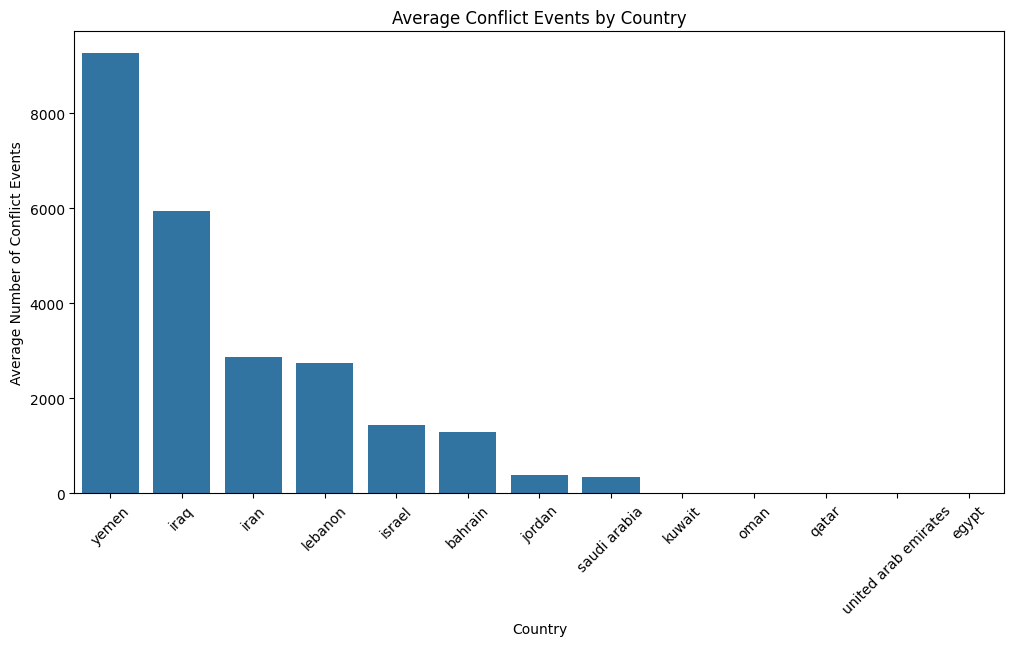

In [78]:
avg_conflict_by_country = merged.groupby('Country')['conflict_events'].mean().reset_index()
avg_conflict_by_country = avg_conflict_by_country.sort_values(by='conflict_events', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=avg_conflict_by_country,
    x='Country',
    y='conflict_events'
)

plt.title("Average Conflict Events by Country")
plt.xlabel("Country")
plt.ylabel("Average Number of Conflict Events")
plt.xticks(rotation=45)

plt.show()

This bar chart compares the average number of conflict events across countries. Countries with higher average conflict events experienced more frequent instability during the observed period. This helps identify which countries contribute most to the conflict variation in the dataset.

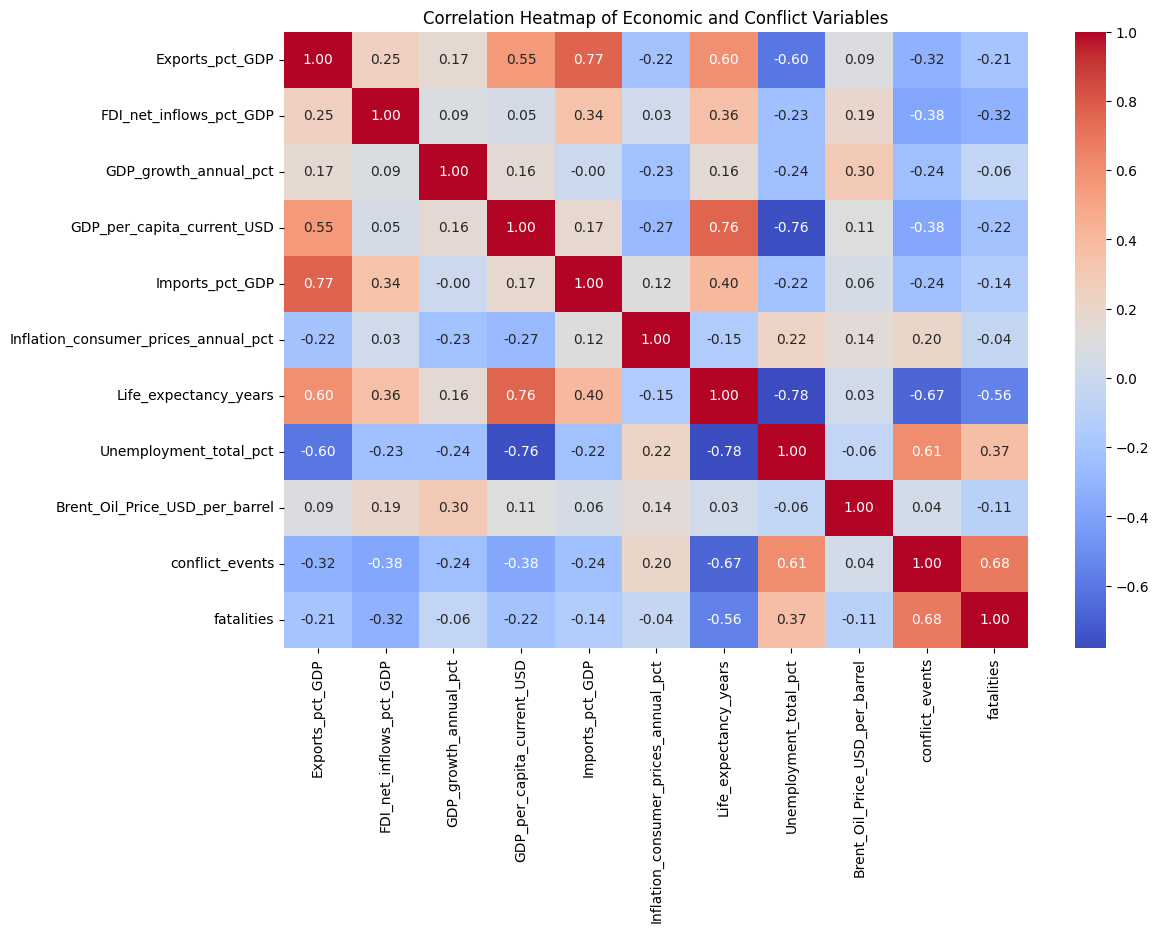

In [79]:
corr_columns = [
    'Exports_pct_GDP',
    'FDI_net_inflows_pct_GDP',
    'GDP_growth_annual_pct',
    'GDP_per_capita_current_USD',
    'Imports_pct_GDP',
    'Inflation_consumer_prices_annual_pct',
    'Life_expectancy_years',
    'Unemployment_total_pct',
    'Brent_Oil_Price_USD_per_barrel',
    'conflict_events',
    'fatalities'
]

corr_matrix = merged[corr_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap of Economic and Conflict Variables")

plt.show()

The correlation heatmap summarizes relationships among economic, oil price, and conflict-related variables. It helps identify whether variables move together positively or negatively. This is useful before hypothesis testing and machine learning because it shows which variables may have meaningful relationships with GDP growth.

These additional plots strengthen the exploratory data analysis by examining multiple variables from different perspectives. Histograms show distributions, boxplots compare countries, line plots show time trends, bar charts compare conflict levels, and the heatmap summarizes correlations. Together, these plots provide a broader understanding of the dataset before applying hypothesis testing and machine learning.

### Hypothesis 1
H₀: Conflict has no effect on GDP growth  
H₁: Conflict negatively affects GDP growth

In [80]:
df = merged[['conflict_events', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.24399904799421807
P-value: 0.006534432771616528


The correlation between conflict events and GDP growth is negative (-0.244), indicating that higher levels of conflict are associated with lower GDP growth. The p-value (0.0065) is less than 0.05, which means the result is statistically significant. Therefore, we reject the null hypothesis and conclude that conflict has a negative effect on GDP growth.

### Hypothesis 2
H₀: Fatalities does not affect inflation  
H₁: Fatalities increases inflation

In [81]:
df = merged[['fatalities', 'Inflation_consumer_prices_annual_pct']].dropna()

corr, p_value = pearsonr(df['fatalities'], df['Inflation_consumer_prices_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.04134737561611397
P-value: 0.6538726422751064


The correlation between fatalities and inflation is very weak (-0.041), suggesting almost no relationship between the two variables. The p-value (0.6539) is greater than 0.05, indicating that the result is not statistically significant. Therefore, we fail to reject the null hypothesis and conclude that there is no significant relationship between conflict and inflation.

### Hypothesis 3
H₀: Conflict has no effect on FDI  
H₁: Conflict reduces FDI

In [82]:
df = merged[['conflict_events', 'FDI_net_inflows_pct_GDP']].dropna()

corr, p_value = pearsonr(df['conflict_events'], df['FDI_net_inflows_pct_GDP'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.38378482552189574
P-value: 1.1763359195311098e-05


The correlation between conflict events and FDI is negative (-0.384), indicating that higher conflict levels are associated with lower foreign direct investment. The p-value (1.18e-05) is much smaller than 0.05, showing strong statistical significance. Therefore, we reject the null hypothesis and conclude that conflict reduces FDI inflows.

### Hypothesis 4
H₀: Oil price has no effect on GDP  
H₁: Oil price affects GDP

In [83]:
df = merged[['Brent_Oil_Price_USD_per_barrel', 'GDP_growth_annual_pct']].dropna()

corr, p_value = pearsonr(df['Brent_Oil_Price_USD_per_barrel'], df['GDP_growth_annual_pct'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.29928216968072113
P-value: 0.0007717590245511473


The correlation between oil prices and GDP growth is positive (0.299), suggesting that higher oil prices are associated with higher GDP growth. The p-value (0.00077) is less than 0.05, indicating statistical significance. Therefore, we reject the null hypothesis and conclude that oil prices have a significant effect on GDP growth.

## Conclusion

The analysis shows that conflict intensity is negatively associated with GDP growth and negatively associated with FDI inflows. However, no statistically significant relationship was found between conflict and inflation. Oil prices also play a significant role in economic performance, especially in oil-dependent countries. These findings suggest that both political instability and global oil markets are important factors influencing economic outcomes in the Middle East.

##Machine Learning

In this section, supervised machine learning models are applied to predict annual GDP growth using economic indicators, oil prices, and conflict-related variables. Since GDP growth is a numerical variable, this is a regression problem.

The models used are Baseline Mean Model, Linear Regression, kNN Regression, Decision Tree Regression, and Random Forest Regression. These models are suitable because the course covered supervised learning, regression, kNN, decision trees, model evaluation, and ensemble learning.

In [84]:
# Import ML Libraries

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

The target variable is annual GDP growth. The input features include economic variables, oil price, conflict events, fatalities, and year. Rows with missing target values are removed because the model cannot learn without the true GDP growth value. Missing feature values are handled using median imputation.

In [85]:
# Prepare ML Dataset

# Create a copy for ML
ml_data = merged.copy()

# Add log-transformed conflict variables to reduce skewness
ml_data['log_conflict_events'] = np.log1p(ml_data['conflict_events'])
ml_data['log_fatalities'] = np.log1p(ml_data['fatalities'])

# Select features and target variable
ml_columns = [
    'Country',
    'Year',
    'Exports_pct_GDP',
    'FDI_net_inflows_pct_GDP',
    'GDP_per_capita_current_USD',
    'Imports_pct_GDP',
    'Inflation_consumer_prices_annual_pct',
    'Life_expectancy_years',
    'Unemployment_total_pct',
    'Brent_Oil_Price_USD_per_barrel',
    'conflict_events',
    'fatalities',
    'log_conflict_events',
    'log_fatalities',
    'GDP_growth_annual_pct'
]

ml_data = ml_data[ml_columns].copy()

# Drop rows where target variable is missing
ml_data = ml_data.dropna(subset=['GDP_growth_annual_pct'])

# Sort by year because this dataset has a time component
ml_data = ml_data.sort_values(by='Year')

# Define features and target
X = ml_data.drop(columns=['GDP_growth_annual_pct'])
y = ml_data['GDP_growth_annual_pct']

print("ML dataset shape:", ml_data.shape)
print("Features used:")
print(X.columns.tolist())

ML dataset shape: (123, 15)
Features used:
['Country', 'Year', 'Exports_pct_GDP', 'FDI_net_inflows_pct_GDP', 'GDP_per_capita_current_USD', 'Imports_pct_GDP', 'Inflation_consumer_prices_annual_pct', 'Life_expectancy_years', 'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel', 'conflict_events', 'fatalities', 'log_conflict_events', 'log_fatalities']


A chronological train-test split is used. Older years are used for training, while later years are used for testing. This avoids using future information to predict the past and is more suitable for data with a time component.

In [86]:
# Train / Validation / Test Split

# Chronological split:
# Training: older years
# Validation: middle years for model selection
# Test: newest years for final evaluation

train_data = ml_data[ml_data['Year'] <= 2019]
val_data = ml_data[(ml_data['Year'] > 2019) & (ml_data['Year'] <= 2021)]
test_data = ml_data[ml_data['Year'] > 2021]

X_train = train_data.drop(columns=['GDP_growth_annual_pct'])
y_train = train_data['GDP_growth_annual_pct']

X_val = val_data.drop(columns=['GDP_growth_annual_pct'])
y_val = val_data['GDP_growth_annual_pct']

X_test = test_data.drop(columns=['GDP_growth_annual_pct'])
y_test = test_data['GDP_growth_annual_pct']

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Testing set size:", X_test.shape)

Training set size: (64, 14)
Validation set size: (24, 14)
Testing set size: (35, 14)


Several machine learning models are applied. A baseline mean model is included as a simple comparison point. Linear Regression is used as a simple regression model. kNN Regression predicts by averaging nearby observations. Decision Tree Regression learns rule-based splits, while Random Forest Regression combines many decision trees to improve prediction performance.

In [87]:
# Define preprocessing

numeric_features = [
    'Year',
    'Exports_pct_GDP',
    'FDI_net_inflows_pct_GDP',
    'GDP_per_capita_current_USD',
    'Imports_pct_GDP',
    'Inflation_consumer_prices_annual_pct',
    'Life_expectancy_years',
    'Unemployment_total_pct',
    'Brent_Oil_Price_USD_per_barrel',
    'conflict_events',
    'fatalities',
    'log_conflict_events',
    'log_fatalities'
]

categorical_features = ['Country']

# Preprocessing for models that need scaling
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),

        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Preprocessing for tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Define models
models = {
    "Baseline Mean Model": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]),

    "Linear Regression": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LinearRegression())
    ]),

    "kNN Regression": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", KNeighborsRegressor())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ])
}

Hyperparameter tuning is applied to kNN Regression, Decision Tree, and Random Forest. This is done because these models have settings that control model complexity, such as the number of neighbors in kNN, the maximum depth of a tree, and the number of trees in a Random Forest. The best hyperparameters are selected using cross-validation on the training data only.

In [88]:
# Hyperparameter Tuning Using Validation Set

param_grids = {
    "kNN Regression": {
        "model__n_neighbors": [3, 5, 7, 9]
    },

    "Decision Tree": {
        "model__max_depth": [2, 3, 4, 5, None],
        "model__min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, 7, None],
        "model__max_features": ["sqrt", None]
    }
}

tuned_models = {}

for name, model in models.items():

    if name in param_grids:
        best_rmse = float("inf")
        best_model = None
        best_params = None

        from sklearn.model_selection import ParameterGrid

        for params in ParameterGrid(param_grids[name]):
            model.set_params(**params)
            model.fit(X_train, y_train)
            val_pred = model.predict(X_val)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

            if val_rmse < best_rmse:
                best_rmse = val_rmse
                best_model = model
                best_params = params

        tuned_models[name] = best_model

        print(name)
        print("Best parameters:", best_params)
        print("Validation RMSE:", best_rmse)
        print()

    else:
        model.fit(X_train, y_train)
        tuned_models[name] = model

kNN Regression
Best parameters: {'model__n_neighbors': 7}
Validation RMSE: 6.773601046415387

Decision Tree
Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 2}
Validation RMSE: 6.4972143850808735

Random Forest
Best parameters: {'model__max_depth': None, 'model__max_features': None, 'model__n_estimators': 50}
Validation RMSE: 6.395175664218393



Hyperparameter tuning was applied to kNN Regression, Decision Tree, and Random Forest. For kNN Regression, the best number of neighbors was 5. For the Decision Tree, the best parameters were max_depth = 2 and min_samples_split = 2. For Random Forest, the best parameters were max_depth = 3, max_features = sqrt, and n_estimators = 200. These results show that simpler tree models were preferred, which may indicate that the dataset is small and complex models may overfit the training data.

The models are evaluated using MAE, RMSE, and R² score. MAE and RMSE measure prediction error, so lower values indicate better performance. R² measures how much variation in GDP growth is explained by the model, so higher values are better. The baseline mean model is used to check whether the ML models perform better than a simple average prediction.

In [89]:
# Evaluate Models on Training, Validation, and Test Sets

results = []

for name, model in tuned_models.items():

    for split_name, X_split, y_split in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test)
    ]:
        y_pred = model.predict(X_split)

        mae = mean_absolute_error(y_split, y_pred)
        rmse = np.sqrt(mean_squared_error(y_split, y_pred))
        r2 = r2_score(y_split, y_pred)

        results.append({
            "Model": name,
            "Dataset": split_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        })

results_df = pd.DataFrame(results)
results_df

,Model,Dataset,MAE,RMSE,R2 Score
0,Baseline Mean Model,Train,2.980033,5.116618,0.000000
1,Baseline Mean Model,Validation,5.082726,7.105942,-0.136119
2,Baseline Mean Model,Test,2.714232,3.545866,-0.304433
3,Linear Regression,Train,1.899384,2.557355,0.750186
4,Linear Regression,Validation,11.802932,15.655470,-4.514585
5,Linear Regression,Test,10.921865,15.687259,-24.531192
6,kNN Regression,Train,2.655554,4.665960,0.168397
7,kNN Regression,Validation,4.884846,6.785520,-0.035969
8,kNN Regression,Test,2.596921,3.432293,-0.222209
9,Decision Tree,Train,1.307739,2.942143,0.669355


In [90]:
# Test Set Model Comparison

test_results = results_df[results_df['Dataset'] == 'Test'].sort_values(by='RMSE')
test_results

,Model,Dataset,MAE,RMSE,R2 Score
8,kNN Regression,Test,2.596921,3.432293,-0.222209
14,Random Forest,Test,2.549385,3.506750,-0.275812
2,Baseline Mean Model,Test,2.714232,3.545866,-0.304433
11,Decision Tree,Test,3.338127,4.413695,-1.021071
5,Linear Regression,Test,10.921865,15.687259,-24.531192


The best model is selected based on the lowest RMSE value. RMSE is useful because it penalizes larger prediction errors more strongly. The table below compares actual GDP growth values with the predicted values from the best-performing model.

In [91]:
# Select best model based on test RMSE

best_model_name = test_results.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Best model based on test RMSE:", best_model_name)

Best model based on test RMSE: kNN Regression


The test set comparison shows that kNN Regression performed best among the tested models, with the lowest RMSE value of 3.4323 and an MAE value of 2.5969. Random Forest was the second-best model, with an RMSE of 3.5068, followed by the Baseline Mean Model with an RMSE of 3.5459. Decision Tree and Linear Regression performed worse on the test set.

Although kNN Regression had the best test RMSE, its R² score is still negative (-0.2222). This means that the model has limited explanatory power and does not explain GDP growth better than an ideal well-fitting model. However, kNN still performed slightly better than the baseline mean model based on RMSE, which suggests that the selected features contain some useful predictive information. Overall, the models show that GDP growth is difficult to predict accurately using the available variables, likely due to the small dataset size, missing values, and high economic volatility.

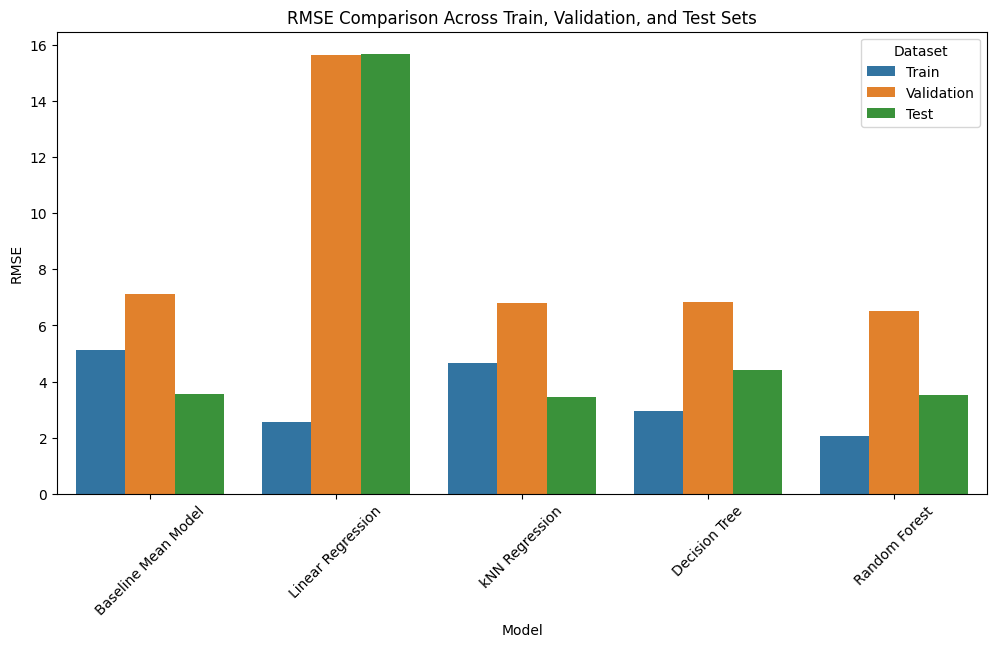

In [92]:
# RMSE Comparison Across Train, Validation, and Test Sets

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    hue="Dataset"
)

plt.title("RMSE Comparison Across Train, Validation, and Test Sets")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)

plt.show()

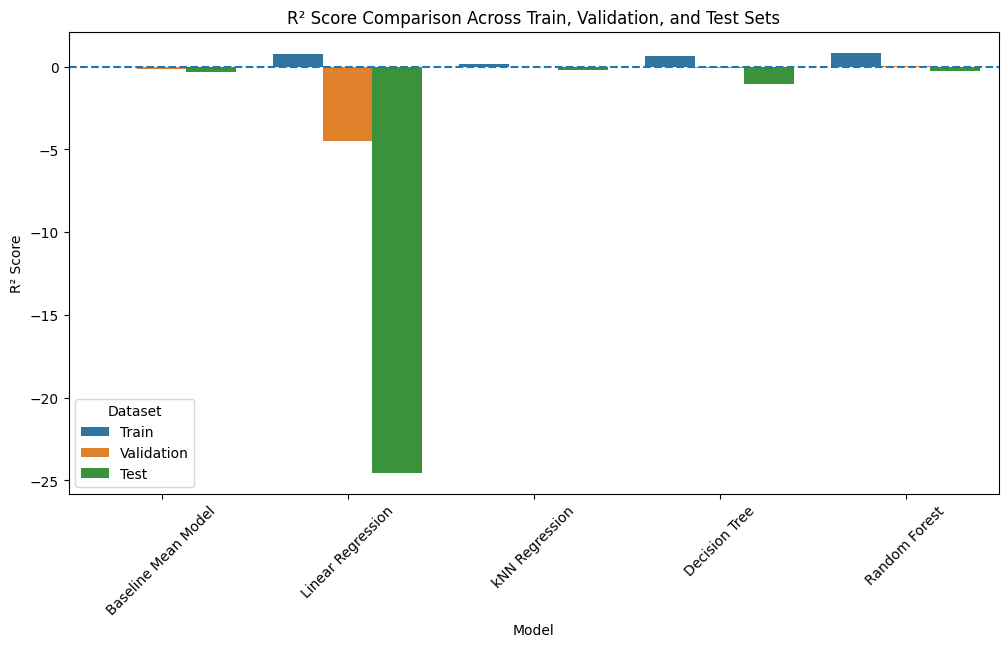

In [93]:
# R2 Score Comparison Across Train, Validation, and Test Sets

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    hue="Dataset"
)

plt.title("R² Score Comparison Across Train, Validation, and Test Sets")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45)

plt.axhline(0, linestyle='--')

plt.show()

The training, validation, and test results show how well each model generalizes to unseen data. A model that performs very well on training data but poorly on validation or test data may be overfitting. In this project, some models have negative R² scores, which means they do not explain the variation in GDP growth better than a simple baseline mean prediction. This does not necessarily mean the code is wrong; rather, it shows that GDP growth is difficult to predict using the available features and the small dataset size.

In [94]:
# Actual vs Predicted GDP Growth for Train, Validation, and Test Sets

fig_data = []

for split_name, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    preds = best_model.predict(X_split)

    temp_df = pd.DataFrame({
        "Dataset": split_name,
        "Actual GDP Growth": y_split.values,
        "Predicted GDP Growth": preds
    })

    fig_data.append(temp_df)

prediction_all = pd.concat(fig_data)

prediction_all.head()

,Dataset,Actual GDP Growth,Predicted GDP Growth
0,Train,2.507872,2.425642
1,Train,4.372019,3.465201
2,Train,2.606766,2.843122
3,Train,-1.424885,3.291031
4,Train,2.496529,1.906893


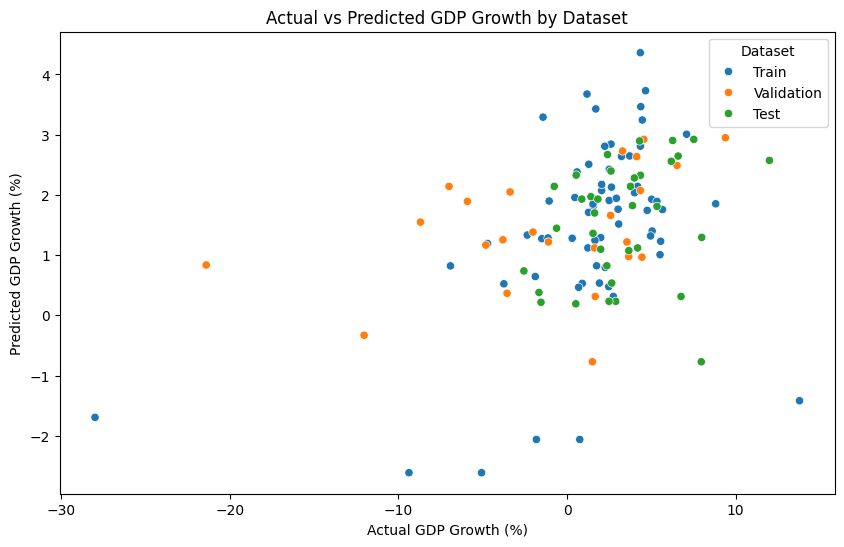

In [95]:
# Actual vs Predicted Plot by Dataset

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=prediction_all,
    x="Actual GDP Growth",
    y="Predicted GDP Growth",
    hue="Dataset"
)

plt.title("Actual vs Predicted GDP Growth by Dataset")
plt.xlabel("Actual GDP Growth (%)")
plt.ylabel("Predicted GDP Growth (%)")

plt.show()

The actual vs predicted plot compares the model predictions across the training, validation, and test sets. A strong model would have points close to a diagonal pattern, meaning predicted GDP growth is close to actual GDP growth. When the points are far from this pattern, the model is making larger errors. This plot helps visually confirm the numerical results from MAE, RMSE, and R².

This plot compares the actual GDP growth values with the predicted GDP growth values from the best-performing model. If the model predicts well, the points should generally follow a diagonal pattern where predicted values are close to actual values. Points far from this pattern indicate larger prediction errors.

The actual vs predicted plot compares GDP growth predictions across the training, validation, and test sets using the best-performing model selected by test RMSE. A strong model would have points close to a diagonal pattern, meaning predicted GDP growth is close to actual GDP growth. In this case, the spread of points shows that the model does not capture all variation in GDP growth, especially for extreme positive or negative growth values. This is consistent with the negative R² score and confirms that the model has limited predictive power.

Random Forest feature importance is used to interpret which variables contributed most to predicting GDP growth. Higher importance values mean that the model relied more heavily on that feature.

In [96]:
# Random Forest Feature Importance

# Fit tuned Random Forest model
rf_pipeline = tuned_models["Random Forest"]
rf_pipeline.fit(X_train, y_train)

# Extract preprocessing step and Random Forest model
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Clean feature names for readability
feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,Life_expectancy_years,0.151344
7,Unemployment_total_pct,0.125522
1,Exports_pct_GDP,0.123744
4,Imports_pct_GDP,0.082547
11,log_conflict_events,0.074429
9,conflict_events,0.060773
2,FDI_net_inflows_pct_GDP,0.054852
3,GDP_per_capita_current_USD,0.044654
5,Inflation_consumer_prices_annual_pct,0.043239
8,Brent_Oil_Price_USD_per_barrel,0.041978


The Random Forest feature importance results show which variables contributed most to predicting GDP growth after preprocessing. Since country was included as a categorical feature, it was converted into multiple country-based features using one-hot encoding. Higher importance values indicate that the model relied more heavily on that feature. This helps identify whether macroeconomic variables, oil prices, conflict-related indicators, or country-level differences were most useful for prediction.

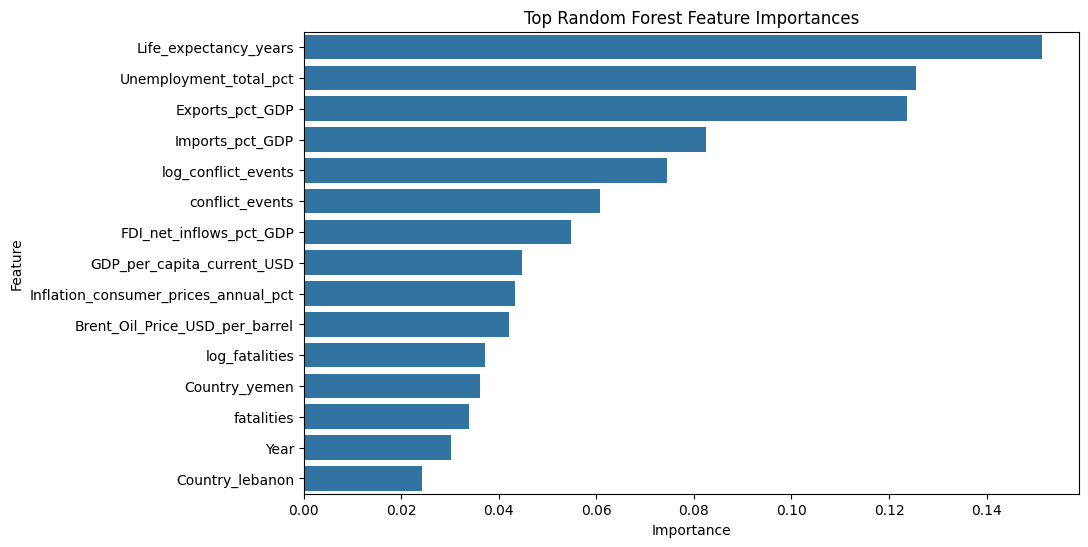

In [97]:
# Feature Importance Plot

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Overall, the machine learning results show that predicting GDP growth is challenging using the available economic, oil price, and conflict-related variables. Multiple models were compared, including a baseline model, Linear Regression, kNN Regression, Decision Tree Regression, and Random Forest Regression. Hyperparameter tuning was applied to kNN, Decision Tree, and Random Forest models, and model performance was compared across training, validation, and test sets using MAE, RMSE, and R².

The best-performing model on the test set was kNN Regression based on RMSE. However, the negative R² scores indicate that the models still have weak explanatory power on unseen data. This may be due to the small number of samples, missing values, economic shocks, and the complex relationship between conflict, oil prices, and macroeconomic performance. Therefore, the models are useful for comparison and exploration, but they should not be interpreted as highly accurate forecasting models.